In [1]:
from pathlib import Path

for p in Path("dataset_extracted").rglob("*"):
    if p.is_dir():
        print(p)

dataset_extracted\google_images
dataset_extracted\State-wise_OLX
dataset_extracted\video_images
dataset_extracted\State-wise_OLX\AN
dataset_extracted\State-wise_OLX\AP
dataset_extracted\State-wise_OLX\AR
dataset_extracted\State-wise_OLX\AS
dataset_extracted\State-wise_OLX\BR
dataset_extracted\State-wise_OLX\CG
dataset_extracted\State-wise_OLX\CH
dataset_extracted\State-wise_OLX\DL
dataset_extracted\State-wise_OLX\DN
dataset_extracted\State-wise_OLX\GA
dataset_extracted\State-wise_OLX\GJ
dataset_extracted\State-wise_OLX\HP
dataset_extracted\State-wise_OLX\HR
dataset_extracted\State-wise_OLX\JH
dataset_extracted\State-wise_OLX\JK
dataset_extracted\State-wise_OLX\KA
dataset_extracted\State-wise_OLX\KL
dataset_extracted\State-wise_OLX\LA
dataset_extracted\State-wise_OLX\MH
dataset_extracted\State-wise_OLX\ML
dataset_extracted\State-wise_OLX\MN
dataset_extracted\State-wise_OLX\MP
dataset_extracted\State-wise_OLX\MZ
dataset_extracted\State-wise_OLX\NL
dataset_extracted\State-wise_OLX\OD
data

In [2]:
!pip install -q ultralytics easyocr opencv-python streamlit

In [3]:
import os
import cv2
import shutil
import random
import re
import xml.etree.ElementTree as ET

from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [4]:
DATASET_ROOT = Path("dataset_extracted")

print("Dataset folder:", DATASET_ROOT.resolve())
print("Exists:", DATASET_ROOT.exists())

Dataset folder: C:\Users\lenovo\AppData\Local\Programs\anaconda-desktop\Number_Plate_Detection\dataset_extracted
Exists: True


In [5]:
from pathlib import Path

print("Folders inside dataset_extracted:\n")

for p in Path("dataset_extracted").rglob("*"):
    if p.is_dir():
        print(p)

Folders inside dataset_extracted:

dataset_extracted\google_images
dataset_extracted\State-wise_OLX
dataset_extracted\video_images
dataset_extracted\State-wise_OLX\AN
dataset_extracted\State-wise_OLX\AP
dataset_extracted\State-wise_OLX\AR
dataset_extracted\State-wise_OLX\AS
dataset_extracted\State-wise_OLX\BR
dataset_extracted\State-wise_OLX\CG
dataset_extracted\State-wise_OLX\CH
dataset_extracted\State-wise_OLX\DL
dataset_extracted\State-wise_OLX\DN
dataset_extracted\State-wise_OLX\GA
dataset_extracted\State-wise_OLX\GJ
dataset_extracted\State-wise_OLX\HP
dataset_extracted\State-wise_OLX\HR
dataset_extracted\State-wise_OLX\JH
dataset_extracted\State-wise_OLX\JK
dataset_extracted\State-wise_OLX\KA
dataset_extracted\State-wise_OLX\KL
dataset_extracted\State-wise_OLX\LA
dataset_extracted\State-wise_OLX\MH
dataset_extracted\State-wise_OLX\ML
dataset_extracted\State-wise_OLX\MN
dataset_extracted\State-wise_OLX\MP
dataset_extracted\State-wise_OLX\MZ
dataset_extracted\State-wise_OLX\NL
datas

In [6]:
from pathlib import Path

# ⭐ DATASET USED HERE

DATASET_ROOT = Path("dataset_extracted")

# Find the actual dataset folder
possible_folders = []

for p in DATASET_ROOT.rglob("*"):
    if p.is_dir():
        folder_names = {x.name for x in p.iterdir() if x.is_dir()}

        if (
            "State-wise_OLX" in folder_names
            or "google_images" in folder_names
            or "video_images" in folder_names
        ):
            possible_folders.append(p)

# If exact folder is not found, search for XML files directly
if possible_folders:
    DATASET = possible_folders[0]
else:
    xml_test = list(DATASET_ROOT.rglob("*.xml"))
    
    if xml_test:
        DATASET = xml_test[0].parent
    else:
        raise FileNotFoundError(
            "❌ XML files nahi mile. Dataset folder ka output bhejo."
        )

print("✅ DATASET FOUND:")
print(DATASET.resolve())

# ⭐ DATASET USED HERE
xml_files = list(DATASET.rglob("*.xml"))

print("\n✅ Total XML files:", len(xml_files))

print("\nFirst 10 XML files:")
for x in xml_files[:10]:
    print(x)

✅ DATASET FOUND:
C:\Users\lenovo\AppData\Local\Programs\anaconda-desktop\Number_Plate_Detection\dataset_extracted\google_images

✅ Total XML files: 440

First 10 XML files:
dataset_extracted\google_images\0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.xml
dataset_extracted\google_images\00b42b2c-f193-4863-b92c-0245cbc816da___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-Petrol-Review-Images-Black-Front-Angle.xml
dataset_extracted\google_images\018b52e6-e9a1-42c2-8ce7-0617e8c8e021___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_sbtb02_auto1.xml
dataset_extracted\google_images\03273806-bb1e-48da-8c8b-a0133a90197a___2014-Skoda-Yeti-Test-Drive.jpg.xml
dataset_extracted\google_images\0369b20e-b432-4409-90f9-2420877aa386___8151536c79159a1557421da5f27f9f0e.jpg.xml
dataset_extracted\google_images\07064c2c-2aa3-4419-91a4-92916de8e54c___mahindra-scorpio-old-car-500x500.jpg.xml
dataset_extracted\google_images\074d85b8-42ec-4d17-9b8e-9e51ae060243___hqdefault.jpg.xml
dataset_extrac

In [7]:
# ⭐ DATASET USED HERE

image_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_files = [
    p for p in DATASET.rglob("*")
    if p.is_file() and p.suffix in image_extensions
]

print("✅ Total images:", len(image_files))

print("\nFirst 10 images:")
for x in image_files[:10]:
    print(x)

✅ Total images: 442

First 10 images:
dataset_extracted\google_images\0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpeg
dataset_extracted\google_images\00b42b2c-f193-4863-b92c-0245cbc816da___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-Petrol-Review-Images-Black-Front-Angle.jpg
dataset_extracted\google_images\018b52e6-e9a1-42c2-8ce7-0617e8c8e021___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_sbtb02_auto1.JPG
dataset_extracted\google_images\03273806-bb1e-48da-8c8b-a0133a90197a___2014-Skoda-Yeti-Test-Drive.jpg.jpeg
dataset_extracted\google_images\0369b20e-b432-4409-90f9-2420877aa386___8151536c79159a1557421da5f27f9f0e.jpg.jpeg
dataset_extracted\google_images\07064c2c-2aa3-4419-91a4-92916de8e54c___mahindra-scorpio-old-car-500x500.jpg.jpeg
dataset_extracted\google_images\074d85b8-42ec-4d17-9b8e-9e51ae060243___hqdefault.jpg.jpeg
dataset_extracted\google_images\07aaab79-71ee-4ea3-a9e6-640191183947___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_1208484d1392541449-nissan-terrano-of

In [8]:
# ⭐ DATASET USED HERE

from collections import defaultdict

image_map = defaultdict(list)

for img in image_files:
    image_map[img.stem.lower()].append(img)

pairs = []

for xml in xml_files:
    stem = xml.stem.lower()

    if stem in image_map:
        for img in image_map[stem]:
            pairs.append((img, xml))

print("✅ Matched image + XML pairs:", len(pairs))

✅ Matched image + XML pairs: 442


In [9]:
# ⭐ DATASET USED HERE

import random

random.seed(42)

random.shuffle(pairs)

split_index = int(0.80 * len(pairs))

train_pairs = pairs[:split_index]
val_pairs = pairs[split_index:]

print("✅ Training samples:", len(train_pairs))
print("✅ Validation samples:", len(val_pairs))

✅ Training samples: 353
✅ Validation samples: 89


In [10]:
from pathlib import Path

BASE = Path("plate_dataset")

train_images = BASE / "train" / "images"
train_labels = BASE / "train" / "labels"

val_images = BASE / "val" / "images"
val_labels = BASE / "val" / "labels"

for folder in [
    train_images,
    train_labels,
    val_images,
    val_labels
]:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ YOLO folders created successfully!")

✅ YOLO folders created successfully!


In [11]:
# ⭐ DATASET USED HERE

import xml.etree.ElementTree as ET

def convert_xml_to_yolo(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")

    image_width = int(size.find("width").text)
    image_height = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / image_width
        y_center = ((ymin + ymax) / 2) / image_height

        width = (xmax - xmin) / image_width
        height = (ymax - ymin) / image_height

        # 0 = license plate
        yolo_lines.append(
            f"0 {x_center:.6f} {y_center:.6f} "
            f"{width:.6f} {height:.6f}"
        )

    return yolo_lines

print("✅ XML → YOLO converter ready!")

✅ XML → YOLO converter ready!


In [12]:
# ⭐ DATASET USED HERE

import shutil

def prepare_dataset(pairs, image_folder, label_folder):

    count = 0

    for image_path, xml_path in pairs:

        try:
            labels = convert_xml_to_yolo(xml_path)

            if not labels:
                continue

            destination_image = image_folder / image_path.name
            destination_label = label_folder / f"{image_path.stem}.txt"

            shutil.copy2(
                image_path,
                destination_image
            )

            with open(destination_label, "w") as f:
                f.write("\n".join(labels))

            count += 1

        except Exception as e:
            print("Skipped:", image_path.name, e)

    return count


train_count = prepare_dataset(
    train_pairs,
    train_images,
    train_labels
)

val_count = prepare_dataset(
    val_pairs,
    val_images,
    val_labels
)

print("✅ Training dataset:", train_count)
print("✅ Validation dataset:", val_count)

✅ Training dataset: 353
✅ Validation dataset: 89


In [13]:
print("Train images :", len(list(train_images.glob("*"))))
print("Train labels :", len(list(train_labels.glob("*.txt"))))

print("Val images   :", len(list(val_images.glob("*"))))
print("Val labels   :", len(list(val_labels.glob("*.txt"))))

Train images : 353
Train labels : 352
Val images   : 89
Val labels   : 89


In [14]:
# ⭐ DATASET USED HERE

yaml_content = f"""
path: {BASE.resolve()}
train: train/images
val: val/images

nc: 1
names:
  0: license_plate
"""

with open(BASE / "data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml created successfully!")
print(yaml_content)

✅ data.yaml created successfully!

path: C:\Users\lenovo\AppData\Local\Programs\anaconda-desktop\Number_Plate_Detection\plate_dataset
train: train/images
val: val/images

nc: 1
names:
  0: license_plate



In [15]:
# ⭐ DATASET USED HERE

print("========== DATASET CHECK ==========")

print("Train images :", len(list(train_images.glob("*"))))
print("Train labels :", len(list(train_labels.glob("*.txt"))))

print("Val images   :", len(list(val_images.glob("*"))))
print("Val labels   :", len(list(val_labels.glob("*.txt"))))

print("===================================")

========== DATASET CHECK ==========
Train images : 353
Train labels : 352
Val images   : 89
Val labels   : 89


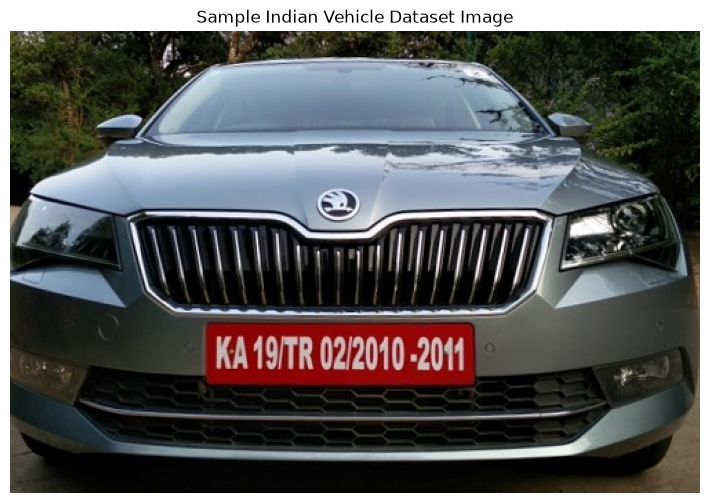

Sample image: plate_dataset\train\images\0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpeg


In [16]:
# ⭐ DATASET USED HERE

import matplotlib.pyplot as plt
import cv2

sample_images = list(train_images.glob("*"))

if len(sample_images) == 0:
    raise FileNotFoundError("Training images nahi mili.")

sample_image_path = sample_images[0]

image = cv2.imread(str(sample_image_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Sample Indian Vehicle Dataset Image")
plt.show()

print("Sample image:", sample_image_path)

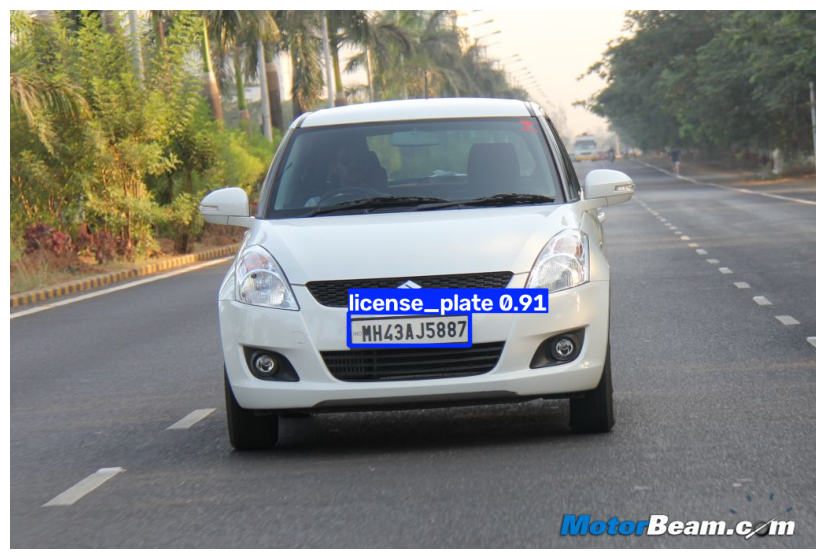

Detected boxes: 1


In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Trained model load karo
model = YOLO("best.pt")

# Apni image ka exact naam likho
image_path = r"C:\Users\lenovo\Downloads\Maruti-Swift-car.jpg"

image = cv2.imread(image_path)

if image is None:
    print("Image not found.Check file name and path.")
else:
    results = model.predict(
        source=image,
        conf=0.10,
        imgsz=960,
        verbose=False
    )

    output = results[0].plot()

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    print("Detected boxes:", len(results[0].boxes))

In [17]:
# ⭐ DATASET USED HERE

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(
    data=str(BASE / "data.yaml"),
    epochs=30,
    imgsz=640,
    batch=8,
    patience=8,
    project="runs",
    name="number_plate",
    exist_ok=True
)

Ultralytics 8.4.173  Python-3.14.7 torch-2.14.1+cpu CPU (Intel Core i5-6300U 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=plate_dataset\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=number_plate, nbs=64, nms=None, opset=None, optimize=False, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000022A7FD2A270>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [22]:
from pathlib import Path
found=list(Path(".").rglob("best.pt"))
print("best.pt files found.")
for p in found:
    print(p)

best.pt files found.
runs\detect\runs\number_plate\weights\best.pt


In [24]:
import shutil
source=found[0]
shutil.copy2(source,"best.pt")
print("best.py ready")

best.py ready


In [20]:
# ⭐ DATASET USED HERE

metrics = model.val(
    data=str(BASE / "data.yaml")
)

print("✅ Validation completed!")

Ultralytics 8.4.173  Python-3.14.7 torch-2.14.1+cpu CPU (Intel Core i5-6300U 2.40GHz)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 483.2441.3 MB/s, size: 152.0 KB)
val: Scanning C:\Users\lenovo\AppData\Local\Programs\anaconda-desktop\Number_Plate_Detection\plate_dataset\val\labels.cache... 89 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 89/89 16.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7s/it 10.2s.3ss
                   all         89         89      0.987      0.978      0.992      0.846
Speed: 3.2ms preprocess, 94.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to C:\Users\lenovo\AppData\Local\Programs\anaconda-desktop\Number_Plate_Detection\runs\detect\val-2
✅ Validation completed!


In [26]:
print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)

mAP50     : 0.9921005154639175
mAP50-95  : 0.8461205367794257


In [27]:
# ⭐ DATASET USED HERE

results = model.predict(
    source=str(sample_image_path),
    conf=0.25,
    save=True
)

print("✅ License plate detection completed!")


image 1/1 C:\Users\lenovo\AppData\Local\Programs\anaconda-desktop\Number_Plate_Detection\plate_dataset\train\images\0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpeg: 448x640 1 license_plate, 161.6ms
Speed: 10.1ms preprocess, 161.6ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\lenovo\AppData\Local\Programs\anaconda-desktop\Number_Plate_Detection\runs\detect\predict-2
✅ License plate detection completed!


In [29]:
import easyocr

reader = easyocr.Reader(
    ['en'],
    gpu=False
)

print("✅ EasyOCR ready!")

Using CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

C:\Users\lenovo\.conda\envs\notebook-env\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


✅ EasyOCR ready!


Using CPU. Note: This module is much faster with a GPU.


Recognized Number Plate: MHL3AJ5887


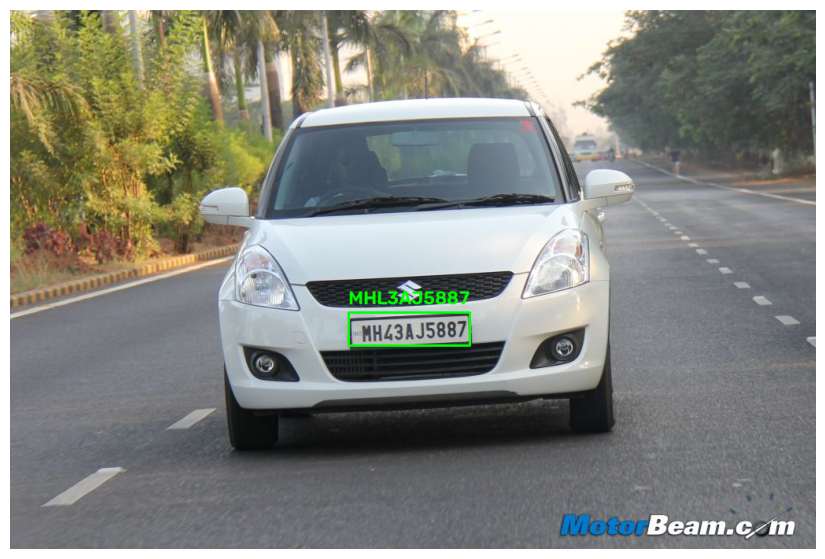

In [30]:
# EasyOCR se number plate read karna

import cv2
import easyocr
import re
import matplotlib.pyplot as plt

reader = easyocr.Reader(["en"], gpu=False)

image = cv2.imread(image_path)

results = model.predict(
    source=image,
    conf=0.10,
    imgsz=960,
    verbose=False
)

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        # Number plate crop karo
        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        # Image ko enlarge karo
        crop = cv2.resize(
            crop, None, fx=3, fy=3,
            interpolation=cv2.INTER_CUBIC
        )

        # OCR se text read karo
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

        text_results = reader.readtext(
            gray,
            detail=1,
            paragraph=False,
            allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
        )

        plate_text = ""

        if text_results:
            best_text = max(text_results, key=lambda x: x[2])
            plate_text = re.sub(
                r"[^A-Z0-9]",
                "",
                best_text[1].upper()
            )

        print("Recognized Number Plate:", plate_text or "Text not recognized")

        cv2.rectangle(
            image, (x1, y1), (x2, y2),
            (0, 255, 0), 2
        )

        if plate_text:
            cv2.putText(
                image, plate_text,
                (x1, max(y1 - 10, 25)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (0, 255, 0), 2
            )

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Total dataset images: 1698
Testing image: dataset_extracted\google_images\07f6d77a-652e-4885-8520-6d405d2f712f___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_840539077_1_1080x720_nissan-terrano-xl-d-thp-110-ps-2016-diesel-.jpg


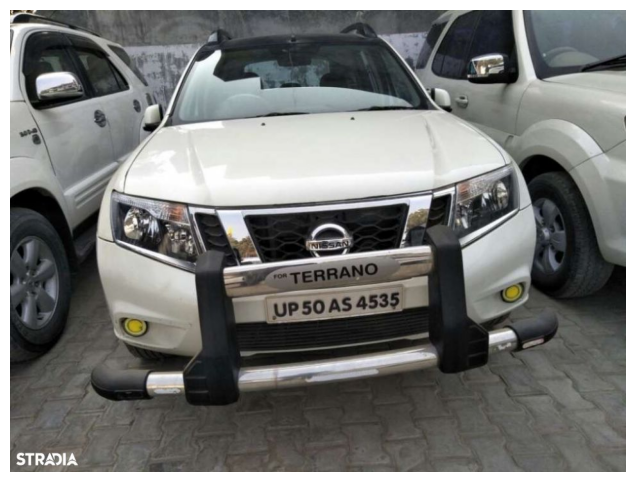

In [3]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# 1. Find dataset images
DATASET_ROOT = Path("dataset_extracted")

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = [
    p for p in DATASET_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in extensions
]

print("Total dataset images:", len(image_files))

# 2. Check images
if not image_files:
    print("Images not found.")

else:
    # 3. Select a test image
    test_path = image_files[min(10, len(image_files) - 1)]
    print("Testing image:", test_path)

    # 4. Display image
    test_img = cv2.imread(str(test_path))

    if test_img is not None:
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    else:
        print("Image are not opened.")

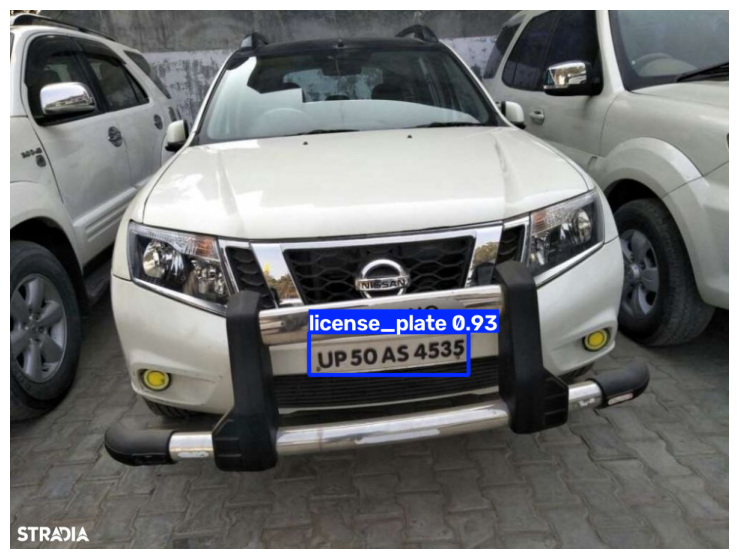

Detected boxes: 1


In [4]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("best.pt")

image = cv2.imread(str(test_path))

results = model.predict(
    source=image,
    conf=0.15,
    imgsz=960,
    verbose=False
)

output = results[0].plot()

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("Detected boxes:", len(results[0].boxes))

In [5]:
import cv2
import easyocr
import matplotlib.pyplot as plt

reader = easyocr.Reader(['en'], gpu=False)

# Detected plate ka crop
results = model.predict(test_img, conf=0.25, verbose=False)

texts = []

for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    plate = test_img[y1:y2, x1:x2]

    if plate.size == 0:
        continue

    # Image ko bada aur clear karo
    plate = cv2.resize(
        plate, None, fx=3, fy=3,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

    # OCR
    detected = reader.readtext(
        gray,
        allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    )

    for item in detected:
        text = item[1].strip()
        if text:
            texts.append(text)

print("Detected number plates:", texts)


Using CPU. Note: This module is much faster with a GPU.
C:\Users\lenovo\.conda\envs\notebook-env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected number plates: ['UPSOAS4535']


In [11]:

%%writefile app.py
import streamlit as st
import cv2
import numpy as np
import pandas as pd
import easyocr
import re

from PIL import Image
from datetime import datetime
from pathlib import Path
from ultralytics import YOLO


# ==========================================
# PAGE CONFIGURATION
# ==========================================

st.set_page_config(
    page_title="Automatic Number Plate Detection and Recognition",
    page_icon="🚘",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ==========================================
# CUSTOM CSS DESIGN
# ==========================================

st.markdown("""
<style>

@import url(
'https://fonts.googleapis.com/css2?family=DM+Sans:wght@400;500;600;700&display=swap'
);

.stApp {
    background:
        radial-gradient(
            circle at top left,
            #172f50,
            #08111f 48%,
            #050b14
        );

    color: #f4f7ff;
    font-family: 'DM Sans', sans-serif;
}

.block-container {
    padding-top: 2rem;
    max-width: 1400px;
}

.hero {
    padding: 35px;
    border-radius: 24px;

    background: linear-gradient(
        120deg,
        #153c62,
        #172347,
        #302452
    );

    border: 1px solid #34577e;
    margin-bottom: 25px;

    box-shadow: 0 12px 35px #00000035;
}

.hero h1 {
    font-size: 38px;
    font-weight: 700;
    color: white;
}

.hero p {
    color: #c3d5ed;
    font-size: 16px;
}

.card {
    background: linear-gradient(
        145deg,
        #14263d,
        #0e1a2b
    );

    padding: 22px;
    border-radius: 18px;

    border: 1px solid #263e5c;
    min-height: 120px;
}

.card-title {
    color: #9bb2ce;
    font-size: 14px;
}

.card-value {
    color: #53d8ff;
    font-size: 27px;
    font-weight: bold;
    margin-top: 10px;
}

.section-title {
    font-size: 24px;
    font-weight: bold;
    margin-top: 25px;
    margin-bottom: 10px;
}

div.stButton > button {
    width: 100%;
    border-radius: 12px;

    background: linear-gradient(
        90deg,
        #087fae,
        #5368e8
    );

    color: white;
    border: none;

    padding: 12px;
    font-weight: bold;

    transition: 0.2s;
}

div.stButton > button:hover {
    background: linear-gradient(
        90deg,
        #079bcf,
        #687cff
    );

    color: white;
    transform: translateY(-2px);
}

div[data-testid="stFileUploader"] {
    background: #102038;
    border-radius: 15px;
    padding: 12px;
}

div[data-testid="stSidebar"] {
    background: #0b1728;
}

div[data-testid="stSidebar"] * {
    color: #edf5ff;
}

</style>
""", unsafe_allow_html=True)


# ==========================================
# SESSION STATE
# ==========================================

if "history" not in st.session_state:
    st.session_state.history = []

if "processed_count" not in st.session_state:
    st.session_state.processed_count = 0

if "last_result" not in st.session_state:
    st.session_state.last_result = None


# ==========================================
# LOAD YOLO AND EASYOCR MODELS
# ==========================================

MODEL_PATH = Path(__file__).resolve().parent / "best.pt"


@st.cache_resource
def load_models():
    model = YOLO(str(MODEL_PATH))
    reader = easyocr.Reader(["en"], gpu=False)
    return model, reader


# ==========================================
# NUMBER PLATE DETECTION FUNCTION
# ==========================================

def detect_number_plates(image_rgb, confidence):
    model, reader = load_models()

    results = model.predict(
        source=image_rgb,
        conf=confidence,
        verbose=False
    )

    annotated_bgr = cv2.cvtColor(
        image_rgb.copy(),
        cv2.COLOR_RGB2BGR
    )

    detected_plates = []

    for result in results:

        if result.boxes is None:
            continue

        for box in result.boxes:

            x1, y1, x2, y2 = map(
                int,
                box.xyxy[0].cpu().tolist()
            )

            yolo_confidence = float(
                box.conf[0].cpu()
            )

            height, width = image_rgb.shape[:2]

            x1 = max(0, min(x1, width - 1))
            x2 = max(0, min(x2, width))
            y1 = max(0, min(y1, height - 1))
            y2 = max(0, min(y2, height))

            if x2 <= x1 or y2 <= y1:
                continue

            plate_crop = image_rgb[y1:y2, x1:x2]

            if plate_crop.size == 0:
                continue

            # Enlarge the plate for OCR
            enlarged = cv2.resize(
                plate_crop,
                None,
                fx=2,
                fy=2,
                interpolation=cv2.INTER_CUBIC
            )

            gray = cv2.cvtColor(
                enlarged,
                cv2.COLOR_RGB2GRAY
            )

            ocr_results = reader.readtext(
                gray,
                allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
            )

            raw_text = "".join(
                item[1] for item in ocr_results
            ).upper()

            plate_text = re.sub(
                r"[^A-Z0-9]",
                "",
                raw_text
            )

            ocr_confidence = (
                float(np.mean([
                    item[2] for item in ocr_results
                ]))
                if ocr_results else 0.0
            )

            display_text = (
                plate_text if plate_text
                else "Plate detected"
            )

            # Draw detection box and label
            cv2.rectangle(
                annotated_bgr,
                (x1, y1),
                (x2, y2),
                (0, 220, 255),
                3
            )

            cv2.putText(
                annotated_bgr,
                display_text[:30],
                (x1, max(25, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 220, 255),
                2,
                cv2.LINE_AA
            )

            detected_plates.append({
                "plate_text": (
                    plate_text if plate_text
                    else "Not recognized"
                ),
                "yolo_confidence": yolo_confidence,
                "ocr_confidence": ocr_confidence,
                "crop": plate_crop
            })

    annotated_rgb = cv2.cvtColor(
        annotated_bgr,
        cv2.COLOR_BGR2RGB
    )

    return annotated_rgb, detected_plates


# ==========================================
# SIDEBAR
# ==========================================

with st.sidebar:

    st.markdown("## 🚘 ANPR STUDIO")

    st.caption("Automatic Number Plate Detection")

    st.divider()

    page = st.radio(
        "NAVIGATION",
        [
            "🏠 Dashboard",
            "📋 Recognition History",
            "ℹ️ About Project"
        ]
    )

    st.divider()

    st.markdown("### ⚙️ Settings")

    show_preview = st.toggle(
        "Show image preview",
        value=True
    )

    confidence = st.slider(
        "Detection confidence",
        min_value=0.10,
        max_value=0.99,
        value=0.50,
        step=0.05
    )

    st.divider()

    st.caption(
        "Built with Python, OpenCV, "
        "EasyOCR and Streamlit."
    )


# ==========================================

# MAIN HEADER

# ==========================================

st.markdown("""

<div class="hero">

```
<div style="
    color:#67e8f9;
    font-size:13px;
    font-weight:600;
    letter-spacing:2px;
    margin-bottom:14px;
">
    ✦ AI-POWERED VEHICLE INTELLIGENCE
</div>

<h1 style="
    font-size:38px;
    line-height:1.2;
    margin-bottom:15px;
">
    🚘 Smart Number Plate
    <br>
    Recognition System
</h1>

<p style="
    font-size:16px;
    line-height:1.8;
    max-width:700px;
    margin-bottom:22px;
">
    Detect vehicle number plates and read their
    numbers automatically using YOLO, Computer
    Vision and EasyOCR.
</p>

<div style="margin-bottom:22px;">
    <span style="
        display:inline-block;
        background:#174d65;
        color:#ffffff;
        padding:8px 13px;
        margin:4px;
        border-radius:20px;
        font-size:13px;
    ">
        🇮🇳 Indian Number Plates
    </span>

    <span style="
        display:inline-block;
        background:#283a68;
        color:#ffffff;
        padding:8px 13px;
        margin:4px;
        border-radius:20px;
        font-size:13px;
    ">
        ⚡ AI-Powered Detection
    </span>

    <span style="
        display:inline-block;
        background:#234b42;
        color:#ffffff;
        padding:8px 13px;
        margin:4px;
        border-radius:20px;
        font-size:13px;
    ">
        🔎 Automatic Text Recognition
    </span>
</div>

<div style="
    background:rgba(255,255,255,0.06);
    border:1px solid rgba(103,232,249,0.25);
    border-radius:14px;
    padding:16px 20px;
    text-align:left;
">
    <div style="
        font-size:15px;
        font-weight:600;
        margin-bottom:8px;
    ">
        👋 Get started in 3 simple steps
    </div>

    <div style="
        font-size:14px;
        line-height:2;
        color:#dbeafe;
    ">
        <b>01</b> &nbsp; Upload a vehicle image
        <br>
        <b>02</b> &nbsp; Click the Analyse button
        <br>
        <b>03</b> &nbsp; View the detected plate and text
    </div>
</div>
```

</div>
""", unsafe_allow_html=True)

# ==========================================
# DASHBOARD PAGE
# ==========================================

if page == "🏠 Dashboard":

    st.markdown(
        '<div class="section-title">'
        '📊 Dashboard Overview</div>',
        unsafe_allow_html=True
    )

    c1, c2, c3 = st.columns(3)

    with c1:
        st.markdown(f"""
        <div class="card">
            <div class="card-title">
                📁 Images Processed
            </div>
            <div class="card-value">
                {st.session_state.processed_count}
            </div>
        </div>
        """, unsafe_allow_html=True)

    with c2:
        st.markdown(f"""
        <div class="card">
            <div class="card-title">
                🧾 Saved Results
            </div>
            <div class="card-value">
                {len(st.session_state.history)}
            </div>
        </div>
        """, unsafe_allow_html=True)

    with c3:
        st.markdown(f"""
        <div class="card">
            <div class="card-title">
                🎯 Confidence Setting
            </div>
            <div class="card-value">
                {confidence:.0%}
            </div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown(
        '<div class="section-title">'
        '🖼️ Upload Vehicle Image</div>',
        unsafe_allow_html=True
    )

    uploaded_file = st.file_uploader(
        "Choose a vehicle image or video",
        type=["jpg", "jpeg", "png","mp4"],
        help="Upload a clear image containing a vehicle."
    )

    if uploaded_file is not None:

        image = Image.open(uploaded_file).convert("RGB")
        image_array = np.array(image)

        # Identify the uploaded image
        upload_id = uploaded_file.name + str(
            len(uploaded_file.getvalue())
        )

        left, right = st.columns(
            [1.2, 0.8],
            gap="large"
        )

        with left:

            if show_preview:
                st.image(
                    image,
                    caption="Uploaded Vehicle Image",
                    use_container_width=True
                )

            st.success("Image uploaded successfully!")

        with right:

            st.markdown("### 🔍 Image Information")

            st.write(
                f"*File name:* {uploaded_file.name}"
            )

            st.write(
                f"*Image width:* {image.width} px"
            )

            st.write(
                f"*Image height:* {image.height} px"
            )

            st.write(
                f"*Detection threshold:* {confidence:.0%}"
            )

            analyse = st.button(
                "🚀 Analyse Number Plate",
                use_container_width=True
            )

            if analyse:

                if not MODEL_PATH.exists():
                    st.error(
                        f"Model file not found: {MODEL_PATH}. "
                        "Place best.pt in the same folder as app.py."
                    )

                else:
                    try:
                        with st.spinner(
                            "YOLO is detecting plates and "
                            "EasyOCR is reading the text..."
                        ):

                            result_image, plates = (
                                detect_number_plates(
                                    image_array,
                                    confidence
                                )
                            )

                        st.session_state.processed_count += 1

                        timestamp = datetime.now().strftime(
                            "%Y-%m-%d %H:%M:%S"
                        )

                        st.session_state.last_result = {
                            "upload_id": upload_id,
                            "image": result_image,
                            "plates": plates
                        }

                        st.session_state.history.append({
                            "Date and Time": timestamp,
                            "Image": uploaded_file.name,
                            "Plates Detected": len(plates),
                            "Recognized Text": (
                                ", ".join(
                                    p["plate_text"] for p in plates
                                )
                                if plates else "No plate detected"
                            ),
                            "Best YOLO Confidence": (
                                f"{max(
                                    (p['yolo_confidence']
                                     for p in plates),
                                    default=0
                                ):.1%}"
                            )
                        })

                    except Exception as e:
                        st.error(f"Detection failed: {e}")

        # Display saved result after Streamlit reruns
        last = st.session_state.last_result

        if last is not None and last["upload_id"] == upload_id:

            st.markdown("### 📝 Recognition Results")

            result_col, details_col = st.columns(
                [1.2, 0.8]
            )

            with result_col:

                st.image(
                    last["image"],
                    caption="Detected Number Plate",
                    use_container_width=True
                )

                success, encoded = cv2.imencode(
                    ".jpg",
                    cv2.cvtColor(
                        last["image"],
                        cv2.COLOR_RGB2BGR
                    )
                )

                if success:
                    st.download_button(
                        "⬇️ Download Detection Image",
                        data=encoded.tobytes(),
                        file_name="number_plate_result.jpg",
                        mime="image/jpeg"
                    )

            with details_col:

                st.metric(
                    "Plates Detected",
                    len(last["plates"])
                )

                if last["plates"]:

                    for i, plate in enumerate(
                        last["plates"], start=1
                    ):

                        with st.container(border=True):

                            st.markdown(f"#### 🚘 Plate {i}")
                            st.code(plate["plate_text"])

                            st.write(
                                "YOLO confidence: "
                                f"{plate['yolo_confidence']:.1%}"
                            )

                            st.write(
                                "OCR confidence: "
                                f"{plate['ocr_confidence']:.1%}"
                            )

                            st.image(
                                plate["crop"],
                                caption="Plate crop",
                                use_container_width=True
                            )

                else:
                    st.warning(
                        "No plate detected. Try a clearer image "
                        "or adjust the confidence slider."
                    )

            st.caption(
                "OCR can confuse similar characters such as O/0 "
                "and I/1. Verify the result manually."
            )

    else:

        st.markdown("""
        <div class="card">

            <h3>🚗 Ready to Get Started?</h3>

            <p>
                Upload a vehicle image to begin
                your number plate recognition workflow.
            </p>

            <p style="color:#9bb2ce;">
                Supported formats: JPG, JPEG and PNG.
            </p>

        </div>
        """, unsafe_allow_html=True)


# ==========================================
# HISTORY PAGE
# ==========================================

elif page == "📋 Recognition History":

    st.markdown("## 📋 Recognition History")

    st.write(
        "Review results saved during this session."
    )

    if st.session_state.history:

        history_df = pd.DataFrame(
            st.session_state.history
        )

        st.dataframe(
            history_df,
            use_container_width=True,
            hide_index=True
        )

        csv_data = history_df.to_csv(
            index=False
        ).encode("utf-8")

        st.download_button(
            "⬇️ Download History CSV",
            data=csv_data,
            file_name="recognition_history.csv",
            mime="text/csv"
        )

        if st.button("🗑️ Clear History"):

            st.session_state.history = []
            st.session_state.last_result = None

            st.success("History cleared.")
            st.rerun()

    else:

        st.info(
            "No recognition results have been saved yet."
        )


# ==========================================
# ABOUT PAGE
# ==========================================

elif page == "ℹ️ About Project":

    st.markdown("## ℹ️ About the Project")

    st.write("""
    Automatic Number Plate Detection and Recognition
    is a computer-vision application designed to locate
    vehicle registration plates and read their characters.
    """)

    st.markdown("### 🧠 Technologies")

    st.markdown("""
    - *Python:* Core programming language
    - *OpenCV:* Image processing
    - *EasyOCR:* Character recognition
    - *Streamlit:* Interactive web interface
    - *Pandas:* Tabular history and CSV export
    """)

    st.markdown("### 🔄 Workflow")

    st.markdown("""
    1. Upload a vehicle image.
    2. Detect the number plate.
    3. Extract the plate region.
    4. Recognise characters using OCR.
    5. Review and save the result.
    """)

    st.warning(
        "Recognition can be incorrect in blurry, "
        "dark or angled images. Verify results manually."
    )


# ==========================================
# FOOTER
# ==========================================

st.divider()

st.markdown("""
<div style="
    text-align:center;
    color:#8198b5;
    padding:10px;
">

    🚘 Automatic Number Plate Detection and Recognition

    <br>

    Smart Vision • Intelligent Recognition • Python

</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [28]:
%%writefile app.py

import streamlit as st
import cv2
import numpy as np
import pandas as pd
import easyocr
import re
import tempfile
import os
from collections import Counter, defaultdict

from PIL import Image
from datetime import datetime
from pathlib import Path
from ultralytics import YOLO


# ==========================================
# PAGE CONFIGURATION
# ==========================================

st.set_page_config(
    page_title="Automatic Number Plate Detection and Recognition",
    page_icon="🚘",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ==========================================
# CUSTOM CSS DESIGN
# ==========================================

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@400;500;600;700&display=swap');

.stApp {
    background: radial-gradient(circle at top left, #172f50, #08111f 48%, #050b14);
    color: #f4f7ff;
    font-family: 'DM Sans', sans-serif;
}

.block-container {
    padding-top: 2rem;
    max-width: 1400px;
}

.hero {
    padding: 35px;
    border-radius: 24px;
    background: linear-gradient(120deg, #153c62, #172347, #302452);
    border: 1px solid #34577e;
    margin-bottom: 25px;
    box-shadow: 0 12px 35px #00000035;
}

.hero h1 {
    font-size: 38px;
    font-weight: 700;
    color: white;
}

.hero p {
    color: #c3d5ed;
    font-size: 16px;
}

.card {
    background: linear-gradient(145deg, #14263d, #0e1a2b);
    padding: 22px;
    border-radius: 18px;
    border: 1px solid #263e5c;
    min-height: 120px;
}

.card-title {
    color: #9bb2ce;
    font-size: 14px;
}

.card-value {
    color: #53d8ff;
    font-size: 27px;
    font-weight: bold;
    margin-top: 10px;
}

.section-title {
    font-size: 24px;
    font-weight: bold;
    margin-top: 25px;
    margin-bottom: 10px;
}

div.stButton > button {
    width: 100%;
    border-radius: 12px;
    background: linear-gradient(90deg, #087fae, #5368e8);
    color: white;
    border: none;
    padding: 12px;
    font-weight: bold;
    transition: 0.2s;
}

div.stButton > button:hover {
    background: linear-gradient(90deg, #079bcf, #687cff);
    color: white;
    transform: translateY(-2px);
}

div[data-testid="stFileUploader"] {
    background: #102038;
    border-radius: 15px;
    padding: 12px;
}

div[data-testid="stSidebar"] {
    background: #0b1728;
}

div[data-testid="stSidebar"] * {
    color: #edf5ff;
}
</style>
""", unsafe_allow_html=True)


# ==========================================
# SESSION STATE
# ==========================================

if "history" not in st.session_state:
    st.session_state.history = []

if "processed_count" not in st.session_state:
    st.session_state.processed_count = 0

if "last_result" not in st.session_state:
    st.session_state.last_result = None


# ==========================================
# LOAD YOLO AND EASYOCR MODELS
# ==========================================

MODEL_PATH = Path(__file__).resolve().parent / "best.pt"


@st.cache_resource
def load_models():
    model = YOLO(str(MODEL_PATH))
    reader = easyocr.Reader(["en"], gpu=False)
    return model, reader


# ==========================================
# NUMBER PLATE DETECTION FUNCTION
# ==========================================

def detect_number_plates(image_rgb, confidence):
    model, reader = load_models()

    results = model.predict(
        source=image_rgb,
        conf=confidence,
        verbose=False
    )

    annotated_bgr = cv2.cvtColor(
        image_rgb.copy(),
        cv2.COLOR_RGB2BGR
    )

    detected_plates = []

    for result in results:
        if result.boxes is None:
            continue

        for box in result.boxes:
            x1, y1, x2, y2 = map(
                int, box.xyxy[0].cpu().tolist()
            )

            yolo_confidence = float(box.conf[0].cpu())

            height, width = image_rgb.shape[:2]

            x1 = max(0, min(x1, width - 1))
            x2 = max(0, min(x2, width))
            y1 = max(0, min(y1, height - 1))
            y2 = max(0, min(y2, height))

            if x2 <= x1 or y2 <= y1:
                continue

            plate_crop = image_rgb[y1:y2, x1:x2]

            if plate_crop.size == 0:
                continue

            enlarged = cv2.resize(
                plate_crop,
                None,
                fx=2,
                fy=2,
                interpolation=cv2.INTER_CUBIC
            )

            gray = cv2.cvtColor(
                enlarged, cv2.COLOR_RGB2GRAY
            )

            ocr_results = reader.readtext(
                gray,
                allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
            )

            raw_text = "".join(
                item[1] for item in ocr_results
            ).upper()

            plate_text = re.sub(
                r"[^A-Z0-9]", "", raw_text
            )

            ocr_confidence = (
                float(np.mean([item[2] for item in ocr_results]))
                if ocr_results else 0.0
            )

            display_text = plate_text or "Plate detected"

            cv2.rectangle(
                annotated_bgr,
                (x1, y1),
                (x2, y2),
                (0, 220, 255),
                3
            )

            cv2.putText(
                annotated_bgr,
                display_text[:30],
                (x1, max(25, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 220, 255),
                2,
                cv2.LINE_AA
            )

            detected_plates.append({
                "plate_text": plate_text or "Not recognized",
                "yolo_confidence": yolo_confidence,
                "ocr_confidence": ocr_confidence,
                "crop": plate_crop
            })

    annotated_rgb = cv2.cvtColor(
        annotated_bgr, cv2.COLOR_BGR2RGB
    )

    return annotated_rgb, detected_plates


# ==========================================
# VIDEO PROCESSING FUNCTION
# ==========================================

def process_video(video_bytes, confidence):
    input_path = None
    output_path = None
    cap = None
    writer = None

    try:
        with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as temp_input:
            temp_input.write(video_bytes)
            input_path = temp_input.name

        cap = cv2.VideoCapture(input_path)
        if not cap.isOpened():
            raise ValueError("Video open nahi hui. Another MP4/AVI video try karein.")

        fps = cap.get(cv2.CAP_PROP_FPS)
        original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if fps <= 0:
            fps = 25.0
        if original_width <= 0 or original_height <= 0:
            raise ValueError("Invalid video dimensions.")

        with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as temp_output:
            output_path = temp_output.name

        writer = cv2.VideoWriter(
            output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps,
            (original_width, original_height)
        )
        if not writer.isOpened():
            raise ValueError("Output video create nahi ho paayi.")

        model, reader = load_models()
        # Keep recent OCR readings for each tracked vehicle/plate.
        track_readings = defaultdict(list)
        track_locked_text = {}
        unique_plates = {}
        frame_count = 0

        progress_bar = st.progress(0)
        status_text = st.empty()
        preview_placeholder = st.empty()

        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break
            frame_count += 1

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            scale = min(1.0, 1280 / max(1, frame_rgb.shape[1]))
            if scale < 1.0:
                frame_rgb = cv2.resize(
                    frame_rgb,
                    (int(frame_rgb.shape[1] * scale), int(frame_rgb.shape[0] * scale))
                )

            # ByteTrack maintains IDs between nearby frames; OCR voting reduces flicker.
            results = model.track(
                source=frame_rgb, conf=confidence, imgsz=1280,
                persist=True, tracker="bytetrack.yaml", verbose=False
            )

            annotated_bgr = cv2.cvtColor(frame_rgb.copy(), cv2.COLOR_RGB2BGR)
            for result in results:
                if result.boxes is None:
                    continue

                boxes = result.boxes
                ids = boxes.id.int().cpu().tolist() if boxes.id is not None else [None] * len(boxes)

                for box, track_id in zip(boxes, ids):
                    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().tolist())
                    det_conf = float(box.conf[0].cpu())
                    h, w = frame_rgb.shape[:2]
                    x1, x2 = max(0, x1), min(w, x2)
                    y1, y2 = max(0, y1), min(h, y2)
                    if x2 <= x1 or y2 <= y1:
                        continue

                    crop = frame_rgb[y1:y2, x1:x2]
                    if crop.size == 0:
                        continue

                    # OCR is run on an enlarged, contrast-enhanced plate crop.
                    enlarged = cv2.resize(crop, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
                    gray = cv2.cvtColor(enlarged, cv2.COLOR_RGB2GRAY)
                    gray = cv2.equalizeHist(gray)
                    ocr_results = reader.readtext(
                        gray, allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789",
                        detail=1, paragraph=False
                    )
                    raw_text = "".join(item[1] for item in ocr_results).upper()
                    plate_text = re.sub(r"[^A-Z0-9]", "", raw_text)
                    ocr_conf = float(np.mean([item[2] for item in ocr_results])) if ocr_results else 0.0

                    # A stable track ID is preferred; use a temporary per-frame key if unavailable.
                    key = str(track_id) if track_id is not None else f"frame{frame_count}_{x1}_{y1}"
                    if plate_text and len(plate_text) >= 4:
                        track_readings[key].append(plate_text)
                        track_readings[key] = track_readings[key][-9:]
                        counts = Counter(track_readings[key])
                        candidate, votes = counts.most_common(1)[0]
                        # Lock only after repeated agreement; otherwise keep showing verification.
                        if votes >= 3:
                            track_locked_text[key] = candidate

                        shown_text = track_locked_text.get(key, "Verifying...")
                        if key in track_locked_text:
                            stable = track_locked_text[key]
                            if stable not in unique_plates:
                                unique_plates[stable] = {
                                    "yolo_confidence": det_conf,
                                    "ocr_confidence": ocr_conf
                                }
                            else:
                                unique_plates[stable]["yolo_confidence"] = max(
                                    unique_plates[stable]["yolo_confidence"], det_conf
                                )
                                unique_plates[stable]["ocr_confidence"] = max(
                                    unique_plates[stable]["ocr_confidence"], ocr_conf
                                )
                    else:
                        shown_text = track_locked_text.get(key, "Verifying...")

                    cv2.rectangle(annotated_bgr, (x1, y1), (x2, y2), (0, 220, 255), 2)
                    cv2.putText(
                        annotated_bgr, shown_text[:30], (x1, max(25, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 220, 255), 2, cv2.LINE_AA
                    )

            annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
            if annotated_rgb.shape[1] != original_width or annotated_rgb.shape[0] != original_height:
                annotated_rgb = cv2.resize(annotated_rgb, (original_width, original_height))
            writer.write(cv2.cvtColor(annotated_rgb, cv2.COLOR_RGB2BGR))

            if frame_count == 1 or frame_count % 10 == 0:
                preview_placeholder.image(
                    annotated_rgb,
                    caption=f"Video processing preview — Frame {frame_count}",
                    use_container_width=True
                )
            if total_frames > 0:
                progress_bar.progress(min(frame_count / total_frames, 1.0))
            status_text.write(
                f"Processing frame {frame_count} / {total_frames if total_frames > 0 else 'unknown'}"
            )

        progress_bar.empty()
        status_text.empty()
        preview_placeholder.empty()

        if frame_count == 0:
            raise ValueError("Video mein readable frames nahi mile.")

        return output_path, unique_plates, frame_count

    except Exception:
        if output_path and os.path.exists(output_path):
            os.remove(output_path)
        raise
    finally:
        if cap is not None:
            cap.release()
        if writer is not None:
            writer.release()
        if input_path and os.path.exists(input_path):
            os.remove(input_path)


# ==========================================
# SIDEBAR
# ==========================================

with st.sidebar:
    st.markdown("## 🚘 ANPR STUDIO")
    st.caption("Automatic Number Plate Detection")
    st.divider()

    page = st.radio(
        "NAVIGATION",
        [
            "🏠 Dashboard",
            "📋 Recognition History",
            "ℹ️ About Project"
        ]
    )

    st.divider()
    st.markdown("### ⚙️ Settings")

    show_preview = st.toggle(
        "Show image preview",
        value=True
    )

    confidence = st.slider(
        "Detection confidence",
        min_value=0.10,
        max_value=0.99,
        value=0.50,
        step=0.05
    )

    st.divider()
    st.caption(
        "Built with Python, OpenCV, EasyOCR and Streamlit."
    )


# ==========================================
# MAIN HEADER
# ==========================================
from pathlib import Path
import streamlit as st

st.set_page_config(
    page_title="ANPR Studio",
    page_icon="🚘",
    layout="wide"
)

banner = Path("assets/anpr_banner.png")

if banner.exists():
    st.image(str(banner), use_container_width=True)

st.title("🚘 Automatic Number Plate Detection and Recognition")
st.caption(
    "AI-powered vehicle detection and number plate recognition"
)

st.info(
    "Upload a vehicle image or video to begin detection."
)


# ==========================================
# DASHBOARD PAGE
# ==========================================

if page == "🏠 Dashboard":

    st.markdown(
        '<div class="section-title">📊 Dashboard Overview</div>',
        unsafe_allow_html=True
    )

    c1, c2, c3 = st.columns(3)

    with c1:
        st.markdown(f"""
        <div class="card">
            <div class="card-title">📁 Files Processed</div>
            <div class="card-value">{st.session_state.processed_count}</div>
        </div>
        """, unsafe_allow_html=True)

    with c2:
        st.markdown(f"""
        <div class="card">
            <div class="card-title">🧾 Saved Results</div>
            <div class="card-value">{len(st.session_state.history)}</div>
        </div>
        """, unsafe_allow_html=True)

    with c3:
        st.markdown(f"""
        <div class="card">
            <div class="card-title">🎯 Confidence Setting</div>
            <div class="card-value">{confidence:.0%}</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown(
        '<div class="section-title">🖼️ Upload Vehicle Image or Video</div>',
        unsafe_allow_html=True
    )

    uploaded_file = st.file_uploader(
        "Choose a vehicle image or video",
        type=["jpg", "jpeg", "png", "jfif", "mp4", "avi", "mov", "mkv"],
        help="Upload a vehicle image or video for number plate recognition."
    )

    if uploaded_file is not None:

        file_bytes = uploaded_file.getvalue()
        upload_id = uploaded_file.name + str(len(file_bytes))

        extension = Path(uploaded_file.name).suffix.lower()

        image_extensions = {".jpg", ".jpeg", ".png",".jfif"}
        video_extensions = {".mp4", ".avi", ".mov", ".mkv"}

        # --------------------------------------
        # IMAGE WORKFLOW
        # --------------------------------------

        if extension in image_extensions:

            try:
                image = Image.open(
                    uploaded_file
                ).convert("RGB")

                image_array = np.array(image)

                left, right = st.columns(
                    [1.2, 0.8], gap="large"
                )

                with left:
                    if show_preview:
                        st.image(
                            image,
                            caption="Uploaded Vehicle Image",
                            use_container_width=True
                        )

                    st.success("Image uploaded successfully!")

                with right:
                    st.markdown("### 🔍 Image Information")
                    st.write(f"File name: {uploaded_file.name}")
                    st.write(f"Image width: {image.width} px")
                    st.write(f"Image height: {image.height} px")
                    st.write(f"Detection threshold: {confidence:.0%}")

                    analyse = st.button(
                        "🚀 Analyse Number Plate",
                        key="analyse_image",
                        use_container_width=True
                    )

                    if analyse:
                        if not MODEL_PATH.exists():
                            st.error(
                                f"Model file not found: {MODEL_PATH}. "
                                "Place best.pt in the same folder as app.py."
                            )
                        else:
                            try:
                                with st.spinner(
                                    "YOLO is detecting plates and EasyOCR "
                                    "is reading the text..."
                                ):
                                    result_image, plates = detect_number_plates(
                                        image_array, confidence
                                    )

                                st.session_state.processed_count += 1

                                st.session_state.last_result = {
                                    "upload_id": upload_id,
                                    "image": result_image,
                                    "plates": plates
                                }

                                timestamp = datetime.now().strftime(
                                    "%Y-%m-%d %H:%M:%S"
                                )

                                st.session_state.history.append({
                                    "Date and Time": timestamp,
                                    "Image": uploaded_file.name,
                                    "Plates Detected": len(plates),
                                    "Recognized Text": ", ".join(
                                        p["plate_text"] for p in plates
                                    ) if plates else "No plate detected",
                                    "Best YOLO Confidence": f"{max(
                                        (p['yolo_confidence'] for p in plates),
                                        default=0
                                    ):.1%}"
                                })

                            except Exception as e:
                                st.error(f"Detection failed: {e}")

                # Display saved image result
                last = st.session_state.last_result

                if (
                    last is not None
                    and last.get("upload_id") == upload_id
                    and "image" in last
                ):
                    st.markdown("### 📝 Recognition Results")

                    result_col, details_col = st.columns([1.2, 0.8])

                    with result_col:
                        st.image(
                            last["image"],
                            caption="Detected Number Plate",
                            use_container_width=True
                        )

                        success, encoded = cv2.imencode(
                            ".jpg",
                            cv2.cvtColor(
                                last["image"], cv2.COLOR_RGB2BGR
                            )
                        )

                        if success:
                            st.download_button(
                                "⬇️ Download Detection Image",
                                data=encoded.tobytes(),
                                file_name="number_plate_result.jpg",
                                mime="image/jpeg"
                            )

                    with details_col:
                        st.metric(
                            "Plates Detected", len(last["plates"])
                        )

                        if last["plates"]:
                            for i, plate in enumerate(
                                last["plates"], start=1
                            ):
                                with st.container(border=True):
                                    st.markdown(f"#### 🚘 Plate {i}")
                                    st.code(plate["plate_text"])
                                    st.write(
                                        f"YOLO confidence: "
                                        f"{plate['yolo_confidence']:.1%}"
                                    )
                                    st.write(
                                        f"OCR confidence: "
                                        f"{plate['ocr_confidence']:.1%}"
                                    )
                                    st.image(
                                        plate["crop"],
                                        caption="Plate crop",
                                        use_container_width=True
                                    )
                        else:
                            st.warning(
                                "No plate detected. Try a clearer image "
                                "or adjust the confidence slider."
                            )

                    st.caption(
                        "OCR can confuse similar characters such as O/0 "
                        "and I/1. Verify the result manually."
                    )

            except Exception as e:
                st.error(f"Could not open image: {e}")

        # --------------------------------------
        # VIDEO WORKFLOW
        # --------------------------------------

        elif extension in video_extensions:

            st.markdown("### 🎬 Video Information")
            st.write(f"File name: {uploaded_file.name}")
            st.write(f"File size: {len(file_bytes) / (1024 * 1024):.2f} MB")

            if show_preview:
                st.video(file_bytes)

            st.info(
                "Upload complete. Click Analyse Video to detect number "
                "plates frame by frame and recognise their text."
            )

            analyse_video = st.button(
                "🚀 Analyse Video",
                key="analyse_video",
                use_container_width=True
            )

            if analyse_video:

                if not MODEL_PATH.exists():
                    st.error(
                        f"Model file not found: {MODEL_PATH}. "
                        "Place best.pt in the same folder as app.py."
                    )

                else:
                    output_path = None

                    try:
                        with st.spinner(
                            "Processing video frames with YOLO + EasyOCR. "
                            "Please wait..."
                        ):
                            output_path, unique_plates, frame_count = (
                                process_video(file_bytes, confidence)
                            )

                        # Read output into memory before removing temp file
                        with open(output_path, "rb") as video_file:
                            output_bytes = video_file.read()

                        st.session_state.processed_count += 1

                        timestamp = datetime.now().strftime(
                            "%Y-%m-%d %H:%M:%S"
                        )

                        recognised_text = (
                            ", ".join(unique_plates.keys())
                            if unique_plates
                            else "No plate detected"
                        )

                        best_confidence = max(
                            (
                                info["yolo_confidence"]
                                for info in unique_plates.values()
                            ),
                            default=0.0
                        )

                        st.session_state.history.append({
                            "Date and Time": timestamp,
                            "Image": uploaded_file.name,
                            "Plates Detected": len(unique_plates),
                            "Recognized Text": recognised_text,
                            "Best YOLO Confidence": f"{best_confidence:.1%}"
                        })

                        st.session_state.last_result = {
                            "upload_id": upload_id,
                            "video_bytes": video_bytes if False else None
                        }

                        st.success(
                            f"Video processed successfully! "
                            f"Frames processed: {frame_count}"
                        )

                        st.markdown("### 🎥 Processed Video")

                        st.video(output_bytes)

                        st.download_button(
                            "⬇️ Download Processed Video",
                            data=output_bytes,
                            file_name="number_plate_detection.mp4",
                            mime="video/mp4",
                            key="download_processed_video"
                        )

                        st.markdown("### 🧾 Recognised Number Plates")

                        if unique_plates:
                            for i, (text, info) in enumerate(
                                unique_plates.items(), start=1
                            ):
                                with st.container(border=True):
                                    st.markdown(f"#### 🚘 Plate {i}")
                                    st.code(text)
                                    st.write(
                                        "Best YOLO confidence: "
                                        f"{info['yolo_confidence']:.1%}"
                                    )
                                    st.write(
                                        "OCR confidence: "
                                        f"{info['ocr_confidence']:.1%}"
                                    )
                        else:
                            st.warning(
                                "No readable number plate was found. "
                                "Try a clearer video or adjust confidence."
                            )

                    except Exception as e:
                        st.error(f"Video processing failed: {e}")

                    finally:
                        if output_path and os.path.exists(output_path):
                            os.remove(output_path)

        else:
            st.error("Unsupported file format.")

    else:
        st.markdown("""
        <div class="card">
            <h3>🚗 Ready to Get Started?</h3>
            <p>Upload a vehicle image or video to begin recognition.</p>
            <p style="color:#9bb2ce;">
                Supported: JPG, JPEG, JFIF, PNG, MP4, AVI, MOV and MKV.
            </p>
        </div>
        """, unsafe_allow_html=True)


# ==========================================
# HISTORY PAGE
# ==========================================

elif page == "📋 Recognition History":

    st.markdown("## 📋 Recognition History")
    st.write("Review results saved during this session.")

    if st.session_state.history:

        history_df = pd.DataFrame(st.session_state.history)

        st.dataframe(
            history_df,
            use_container_width=True,
            hide_index=True
        )

        csv_data = history_df.to_csv(
            index=False
        ).encode("utf-8")

        st.download_button(
            "⬇️ Download History CSV",
            data=csv_data,
            file_name="recognition_history.csv",
            mime="text/csv"
        )

        if st.button("🗑️ Clear History"):
            st.session_state.history = []
            st.session_state.last_result = None
            st.success("History cleared.")
            st.rerun()

    else:
        st.info("No recognition results have been saved yet.")


# ==========================================
# ABOUT PAGE
# ==========================================

elif page == "ℹ️ About Project":

    st.markdown("## ℹ️ About the Project")

    st.write("""
    Automatic Number Plate Detection and Recognition is a
    computer-vision application designed to locate vehicle
    registration plates and read their characters from images
    and videos.
    """)

    st.markdown("### 🧠 Technologies")

    st.markdown("""
    - **Python:** Core programming language
    - **YOLO:** Number plate detection
    - **OpenCV:** Image and video processing
    - **EasyOCR:** Character recognition
    - **Streamlit:** Interactive web interface
    - **Pandas:** Tabular history and CSV export
    """)

    st.markdown("### 🔄 Workflow")

    st.markdown("""
    1. Upload a vehicle image or video.
    2. Detect the number plate.
    3. Extract the plate region.
    4. Recognise characters using OCR.
    5. Review or download the processed result.
    """)

    st.warning(
        "Recognition can be incorrect in blurry, dark or angled "
        "images and videos. Verify results manually."
    )


# ==========================================
# FOOTER
# ==========================================

st.divider()

st.markdown("""
<div style="text-align:center;color:#8198b5;padding:10px;">
    🚘 Automatic Number Plate Detection and Recognition
    <br>
    Smart Vision • Intelligent Recognition • Python
</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [29]:
import subprocess
import sys
import os

# Stop any old Streamlit process on port 8501 if needed
log_file = open("streamlit_log.txt", "w")

process = subprocess.Popen(
    [
        sys.executable, "-m", "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT,
    cwd=os.getcwd()
)

print("Streamlit start command sent.")
print("Open this URL: http://localhost:8501")

Streamlit start command sent.
Open this URL: http://localhost:8501


In [20]:

from pathlib import Path

for p in Path(".").rglob("*"):
    if p.is_file() and p.suffix.lower() in [".pt", ".mp4", ".avi", ".mov", ".mkv"]:
        print(p)

best.pt
yolo11n.pt
runs\detect\runs\number_plate\weights\best.pt
runs\detect\runs\number_plate\weights\last.pt


Model file exists: True
Video file exists: True
Model classes: {0: 'license_plate'}
Total video frames: 2890
Frame 0: detected boxes = 2


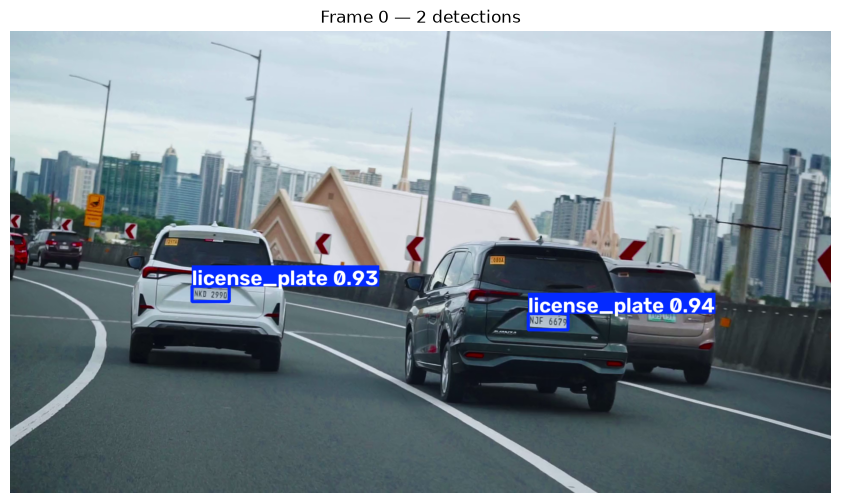

Frame 321: detected boxes = 3
Frame 642: detected boxes = 3
Frame 963: detected boxes = 2
Frame 1284: detected boxes = 6


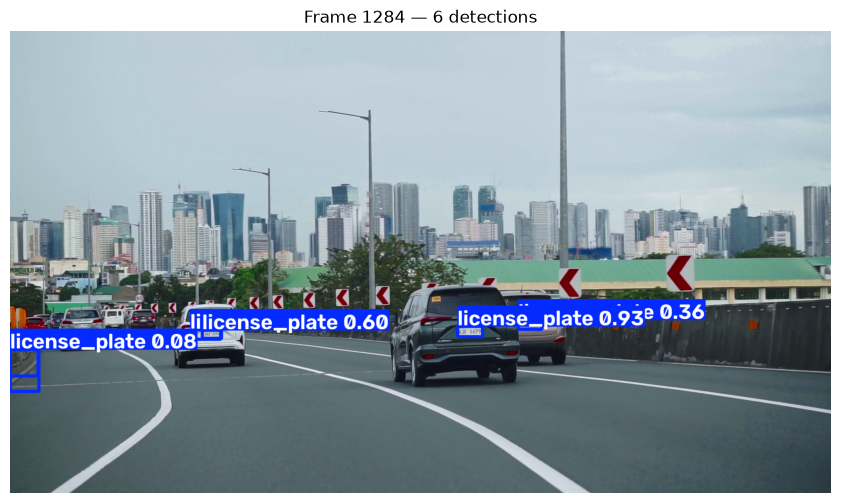

Frame 1605: detected boxes = 3
Frame 1926: detected boxes = 2
Frame 2247: detected boxes = 1
Frame 2568: detected boxes = 1
Frame 2889: detected boxes = 1


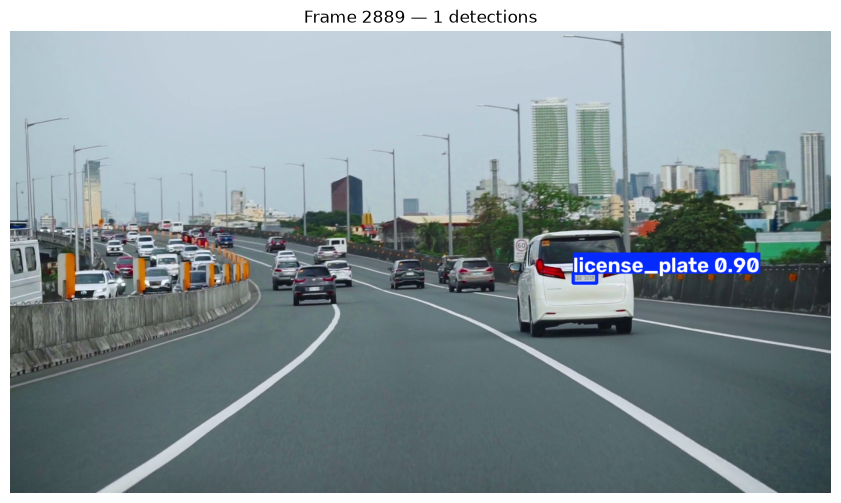

In [25]:

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Apni files ke paths check karein
#MODEL_PATH = Path("best.pt")
MODEL_PATH = Path(r"runs\detect\runs\number_plate\weights\best.pt")
VIDEO_PATH = Path(r"C:\Users\lenovo\Downloads\15123032_1920_1080_60fps.mp4")

print("Model file exists:", MODEL_PATH.exists())
print("Video file exists:", VIDEO_PATH.exists())

if not MODEL_PATH.exists():
    print("ERROR: best.pt nahi mili. Model ka correct path set karein.")
elif not VIDEO_PATH.exists():
    print("ERROR: Video nahi mili. VIDEO_PATH mein correct full path dein.")
else:
    model = YOLO(str(MODEL_PATH))
    cap = cv2.VideoCapture(str(VIDEO_PATH))

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print("Model classes:", model.names)
    print("Total video frames:", total)

    if total > 0:
        for i in range(10):
            # Video ke alag-alag hisson se frame lein
            frame_no = int(i * (total - 1) / 9) if total > 1 else 0
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
            ok, frame = cap.read()

            if not ok:
                print("Frame read failed:", frame_no)
                continue

            results = model.predict(
                source=frame,
                conf=0.05,
                imgsz=1280,
                verbose=False
            )

            count = len(results[0].boxes)
            print(f"Frame {frame_no}: detected boxes = {count}")

            if i in (0, 4, 9):
                annotated = results[0].plot()
                plt.figure(figsize=(12, 6))
                plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
                plt.title(f"Frame {frame_no} — {count} detections")
                plt.axis("off")
                plt.show()

    cap.release()

Using CPU. Note: This module is much faster with a GPU.



Frame 0:
Plate 1: NJF6679


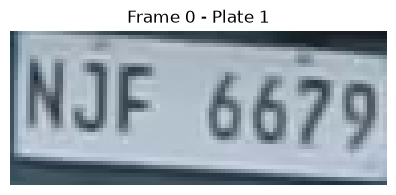

Plate 2: NKD2990


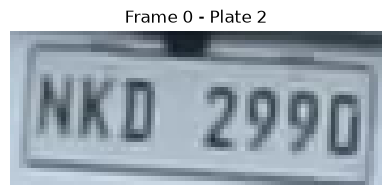


Frame 321:
Plate 1: NJF6679


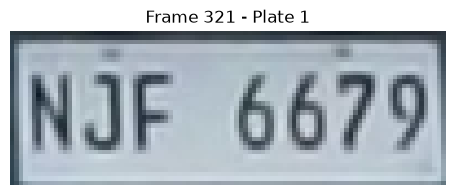

Plate 2: NKD2990


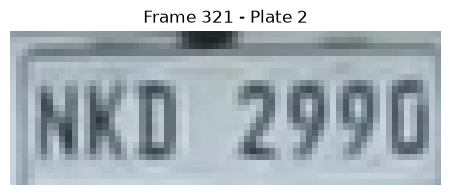

Plate 3:Not Detected


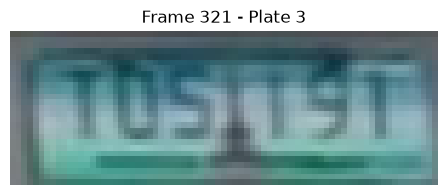


Frame 642:
Plate 1: NJF6679


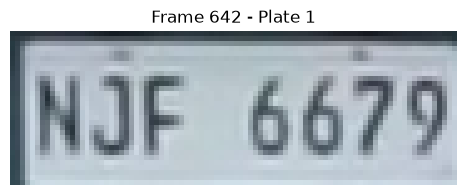

Plate 2: NKD2990


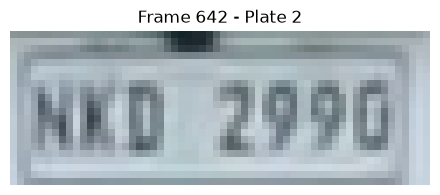

Plate 3:Not Detected


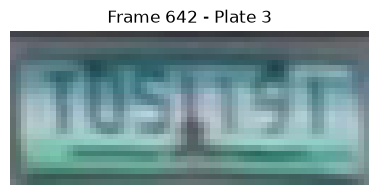


Frame 963:
Plate 1: MJF6679


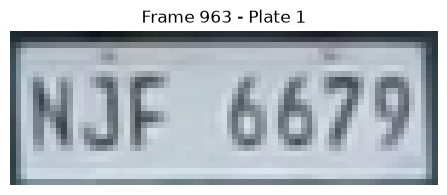

Plate 2:Not Detected


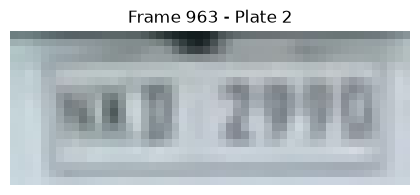


Frame 1284:
Plate 1: MJF6679


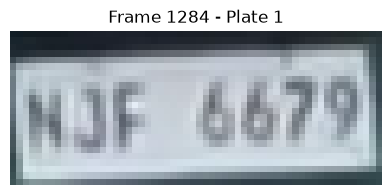

Plate 2:Not Detected


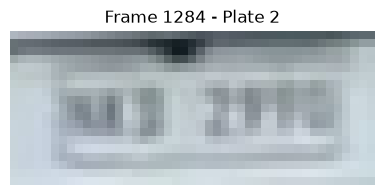

Plate 3:Not Detected


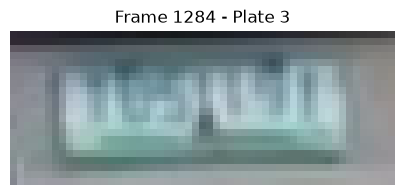

Plate 4:Not Detected


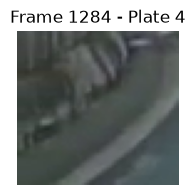

Plate 5:Not Detected


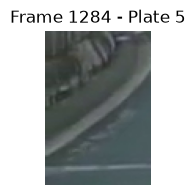

Plate 6:Not Detected


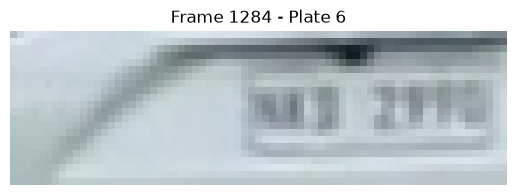


Frame 1605:
Plate 1: DCC9372


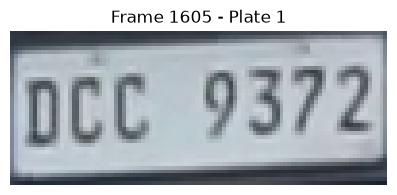

Plate 2:Not Detected


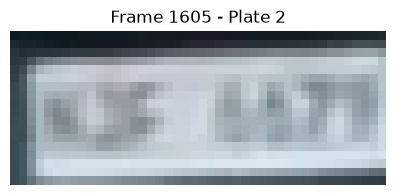

Plate 3:Not Detected


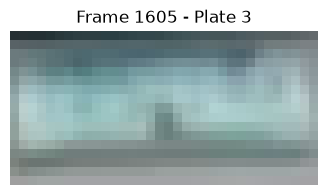


Frame 1926:
Plate 1: ICC9372


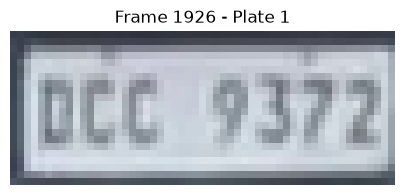

Plate 2:Not Detected


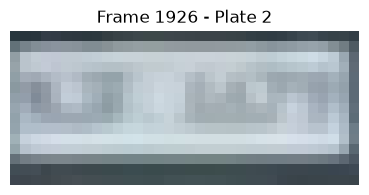


Frame 2247:
Plate 1:Not Detected


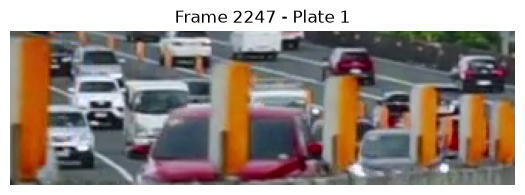


Frame 2568:
Plate 1: DAO2619


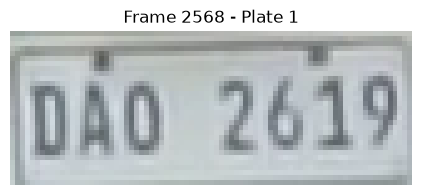


Frame 2889:
Plate 1: 10


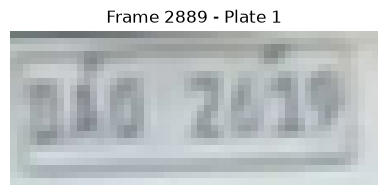

In [26]:

import cv2
import easyocr
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Apne existing model aur video ke paths
MODEL_PATH = Path("best.pt")
VIDEO_PATH = Path(r"C:\Users\lenovo\Downloads\15123032_1920_1080_60fps.mp4")

# Models load karein
model = YOLO(str(MODEL_PATH))
reader = easyocr.Reader(['en'], gpu=False)

cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    print("Give the correct video path.")
else:
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Video ke 10 alag frames test karein
    for i in range(10):
        frame_no = int(i * (total - 1) / 9) if total > 1 else 0
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
        ok, frame = cap.read()

        if not ok:
            continue

        results = model.predict(
            source=frame,
            conf=0.05,
            imgsz=1280,
            verbose=False
        )[0]

        print(f"\nFrame {frame_no}:")

        if len(results.boxes) == 0:
            print("No number plate is detected.")
            continue

        for j, box in enumerate(results.boxes):
            x1, y1, x2, y2 = map(
                int, box.xyxy[0].tolist()
            )

            # Coordinates ko image ke andar rakhein
            h, w = frame.shape[:2]
            x1, x2 = max(0, x1), min(w, x2)
            y1, y2 = max(0, y1), min(h, y2)

            plate = frame[y1:y2, x1:x2]

            if plate.size == 0:
                continue

            # OCR se number plate read karein
            gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

            ocr_results = reader.readtext(
                gray,
                allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
                detail=1
            )

            if ocr_results:
                text = " ".join(
                    item[1] for item in ocr_results
                    if item[1].strip()
                )
                print(f"Plate {j+1}: {text}")
            else:
                print(f"Plate {j+1}:Not Detected")

            # Crop ki hui plate dikhayein
            plt.figure(figsize=(7, 2))
            plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
            plt.title(f"Frame {frame_no} - Plate {j+1}")
            plt.axis("off")
            plt.show()

    cap.release()